# 01 — Exploratory Data Analysis (EDA)
Verify data quality, distributions, and confirm no data leakage before modeling.

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_valid_cam
from src.feature_engineering import derive_targets, build_intake_record, encode_features, build_training_dataset
from src.config import LEAKY_COLS, PHASE_A_FEATURES

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load data

In [ ]:
cam = load_valid_cam('../data/raw/D4G_CAM_Final.xlsx')
print(cam.shape)
cam.head(3)

Loaded CAM: 59,624 rows, 10,118 unique clients
After cut-off (2025-02-28): 9,576 valid clients (542 excluded — entered system too recently)
(58656, 40)


,Date,Dummy Client ID,Date Client Record Was Created,Geographic Region,Age,Gender Identity,Days Since Last Activity,Indigenous Status,Veteran Status,Citizenship and Immigration Status,Last Known Housing Type,Recent Interaction Module,Recent Interaction Date,Household Type,Acuity - Triage Start Date,Acuity - Triage Score,Acuity - Triage Type,Acuity - Full Assessment Start Date,Acuity - Full Assessment Score,Acuity - Full Assessment Type,Tri-Morbidity,Current Episode Days Homeless,Days Homeless in Lifetime,Chronic Homelessness Y/N,Days Homeless In Past Year,Days Homeless in the Last 3 Years,Days Unsheltered Homeless in Lifetime,Percentage of Housing History Completed Over Last 30 Days,First Homeless Episode Y/N,First Homeless Episode In Last 30 Days Y/N,New Client In 30 Days Y/N,Returned From Housing Y/N,Returned From Inactive Y/N,City Name Where Last Housed,Housing Search Started Date,Housing Secured Date,Expected Move In Date,Service Restrictions,Primary Income Type,Monthly Primary Income Amount
0,2024-04-30,F894U60,2019-09-11 12:48:43,NaN,30,Female,71.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,NaN,Goods and Services,2024-03-05 11:46:52,Single,NaT,NaN,NaN,NaT,NaN,NaN,N,NaN,NaN,N,NaN,NaN,NaN,0.0,N,N,N,N,N,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,2024-04-30,C387D34,2019-10-02 10:04:36,NaN,59,Female,72.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,NaN,Goods and Services,2024-03-04 14:00:28,Single,NaT,NaN,NaN,NaT,NaN,NaN,N,NaN,NaN,N,NaN,NaN,NaN,0.0,N,N,N,N,N,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,2024-04-30,V630C41,2022-03-01 13:06:54,NaN,60,Female,62.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,NaN,Goods and Services,2024-03-14 13:10:56,Single,NaT,NaN,NaN,NaT,NaN,NaN,N,NaN,NaN,N,NaN,NaN,NaN,0.0,N,N,N,N,N,NaN,NaT,NaT,NaT,NaN,NaN,NaN


## 2. Target distribution

Targets derived: 3,259 chronic (34.0%) / 6,317 non-chronic
became_chronic
0    6317
1    3259
Name: count, dtype: int64

Chronic rate: 34.0%


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  targets = cam.groupby('Dummy Client ID').apply(client_target).reset_index()


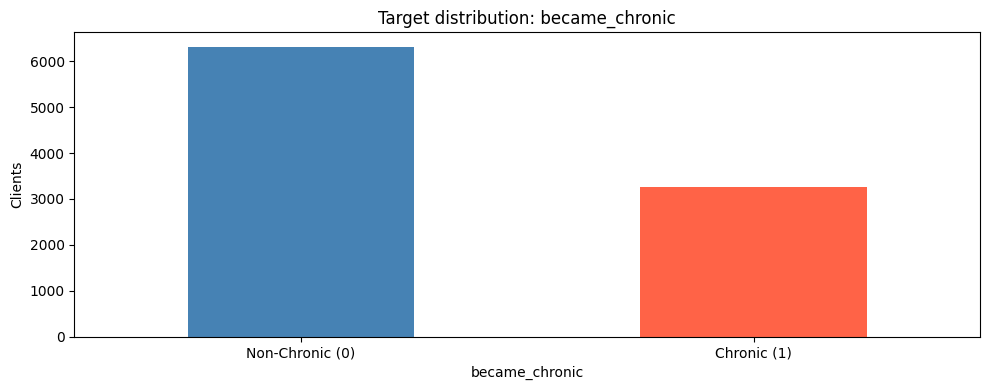

In [ ]:
targets = derive_targets(cam)
print(targets['became_chronic'].value_counts())
print(f"\nChronic rate: {targets['became_chronic'].mean():.1%}")

targets['became_chronic'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Target distribution: became_chronic')
plt.xticks([0, 1], ['Non-Chronic (0)', 'Chronic (1)'], rotation=0)
plt.ylabel('Clients')
plt.tight_layout()
plt.show()

## 3. Build training dataset

In [ ]:
training_df = build_training_dataset(cam)
print(f"Shape: {training_df.shape}")
print(f"\nExpected: (9576, ~40+) rows x cols")
training_df.head(10)

Targets derived: 3,259 chronic (34.0%) / 6,317 non-chronic
Intake records built: 9,576 clients

Training dataset: 9,576 rows x 69 cols
Phase A features available: 19/19
Phase B features available: 23/23
Shape: (9576, 69)

Expected: (9576, ~40+) rows x cols


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  targets = cam.groupby('Dummy Client ID').apply(client_target).reset_index()


,Dummy Client ID,Date,Date Client Record Was Created,Geographic Region,Age,Gender Identity,Days Since Last Activity,Indigenous Status,Veteran Status,Citizenship and Immigration Status,Last Known Housing Type,Recent Interaction Module,Recent Interaction Date,Household Type,Acuity - Triage Start Date,Acuity - Triage Score,Acuity - Triage Type,Acuity - Full Assessment Start Date,Acuity - Full Assessment Score,Acuity - Full Assessment Type,Tri-Morbidity,Current Episode Days Homeless,Days Homeless in Lifetime,Chronic Homelessness Y/N,Days Homeless In Past Year,...,indigenous_status,veteran_status,immigration_status,household_type,age,last_housed_location,is_local_region,geo_missing,has_income,income_source,income_source_missing,yearly_income,yearly_income_missing,annual_income_range,has_very_low_income,tri_morbidity,returned_from_housing,first_homeless_episode,became_chronic,date_became_chronic,days_to_chronic,last_known_housing_category,last_known_housing_missing,first_intervention_type,days_since_last_activity
0,A102A28,2025-07-31,2024-11-02 17:33:24,Kitchener,39,Male,28.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - HOF ShelterCare,Admissions,2025-07-29 03:00:42,Single,NaT,NaN,Select an option,2025-06-25 11:44:00,24.0,SPDAT_V4,N,297.0,297.0,Y,297.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,39,Waterloo Region,1.0,0,1,Ontario Works (OW),0,8400.0,0,"Very Low (0-19,999)",1,0,0,1,1,2025-07-31,270.0,Emergency Shelter,0,Admissions,28.0
1,A109E15,2023-01-31,2022-07-30 23:13:41,None,9,Male,181.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: Motels - YW,Admissions,2022-08-04 18:05:00,Family,NaT,NaN,None,NaT,NaN,None,N,NaN,5.0,N,5.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Family,9,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Motel,0,Admissions,181.0
2,A110B58,2024-07-31,2007-02-21 00:00:00,This Community,32,Female,2.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - Cambridge Shelter,Goods and Services,2024-08-13 15:27:00,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,9.0,N,NaN,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,32,Never Housed/Unknown,1.0,0,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Cambridge Shelter,0,Goods and Services,2.0
3,A116Q99,2024-08-31,2024-08-22 15:40:42,None,50,Female,24.0,Métis,Not a Veteran,Canadian Citizen - Born in Canada,None,Goods and Services,2024-08-22 15:40:51,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,NaN,N,NaN,...,Indigenous,Not a Veteran,Canadian Citizen,Single,50,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Unknown,1,Goods and Services,24.0
4,A121N81,2025-07-31,2024-08-15 12:10:28,None,45,Male,165.0,Non-Indigenous,Not a Veteran,Refugee Claimant,Stay at: Motels - YW Families,Case Management,2025-03-14 13:39:00,Family,NaT,NaN,Select an option,NaT,NaN,Select an option,N,NaN,63.0,N,52.0,...,Non-Indigenous,Not a Veteran,Refugee,Family,45,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Motel,0,Case Management,165.0
5,A126F64,2023-07-31,2023-07-05 15:11:29,None,63,Female,27.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,None,Goods and Services,2023-07-05 15:11:49,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,NaN,N,NaN,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,63,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Unknown,1,Goods and Services,27.0
6,A130G98,2025-07-31,2024-01-15 13:26:56,None,67,Male,28.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - HOF ShelterCare,Admissions,2025-07-29 03:00:42,Single,NaT,NaN,Select an option,2025-06-17 13:00:00,12.0,SPDAT_V4,N,756.0,1729.0,Y,365.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,67,Waterloo Region,NaN,1,1,Pension,0,14472.0,0,"Very Low (0-19,999)",1,0,0,0,1,2025-07-31,562.0,Emergency Shelter,0,Admissions,28.0
7,A130Q87,2023-07-31,

## 4. Verify: no leaky columns in feature matrix

In [ ]:
from src.feature_engineering import get_X_y
X, y = get_X_y(training_df)

leaky_in_X = [c for c in LEAKY_COLS if c in X.columns]
if leaky_in_X:
    print(f'WARNING: Leaky columns found in X: {leaky_in_X}')
else:
    print('OK — No leaky columns in feature matrix X')

print(f"\nX shape: {X.shape}")
print(f"Features: {list(X.columns)}")

OK — No leaky columns in feature matrix X

X shape: (9576, 23)
Features: ['entry_year', 'entry_season', 'days_before_first_snapshot', 'age', 'gender', 'indigenous_status', 'veteran_status', 'immigration_status', 'household_type', 'has_income', 'income_source', 'income_source_missing', 'yearly_income', 'yearly_income_missing', 'annual_income_range', 'has_very_low_income', 'tri_morbidity', 'returned_from_housing', 'first_homeless_episode', 'last_known_housing_category', 'last_known_housing_missing', 'first_intervention_type', 'days_since_last_activity']


## 5. Null rates per feature

Null rates in feature matrix:
income_source    0.572577
yearly_income    0.568087


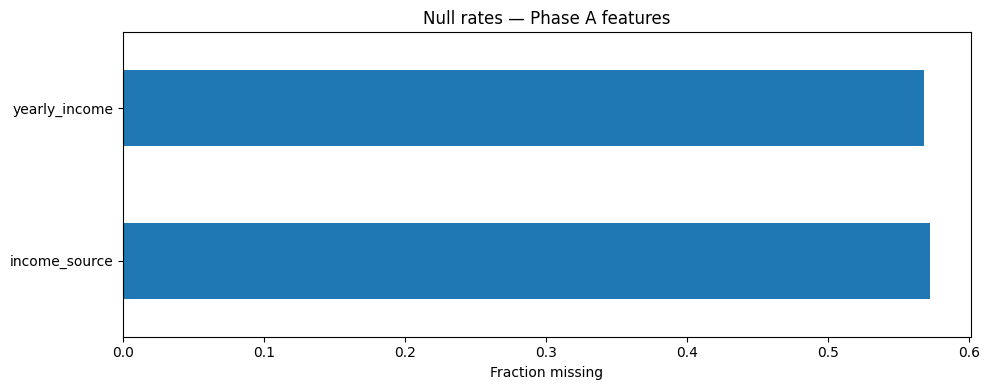

In [ ]:
null_rates = X.isna().mean().sort_values(ascending=False)
print("Null rates in feature matrix:")
print(null_rates[null_rates > 0].to_string())

null_rates[null_rates > 0].plot(kind='barh')
plt.title('Null rates — Phase A features')
plt.xlabel('Fraction missing')
plt.tight_layout()
plt.show()

## 6. Chronic rate by key features

/var/folders/_s/b1t0rhvs0tzgb3br2ysj5qfc0000gn/T/ipykernel_26270/3293648741.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(col)['became_chronic'].mean().sort_values(ascending=True)
/var/folders/_s/b1t0rhvs0tzgb3br2ysj5qfc0000gn/T/ipykernel_26270/3293648741.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(col)['became_chronic'].mean().sort_values(ascending=True)
/var/folders/_s/b1t0rhvs0tzgb3br2ysj5qfc0000gn/T/ipykernel_26270/3293648741.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass o

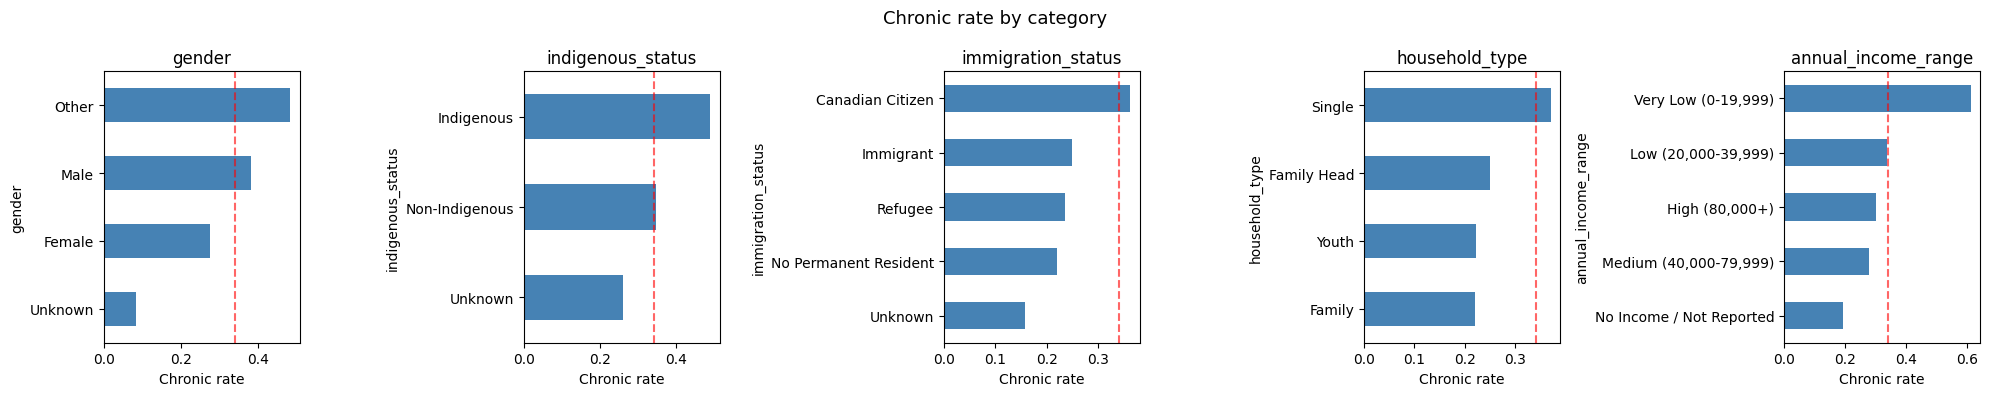

In [ ]:
df = X.copy()
df['became_chronic'] = y

cat_cols = ['gender', 'indigenous_status', 'immigration_status',
            'household_type', 'annual_income_range']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['became_chronic'].mean().sort_values(ascending=True)
    rates.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Chronic rate')
    ax.axvline(y.mean(), color='red', linestyle='--', alpha=0.6, label='Overall')

plt.suptitle('Chronic rate by category', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Age and income distributions

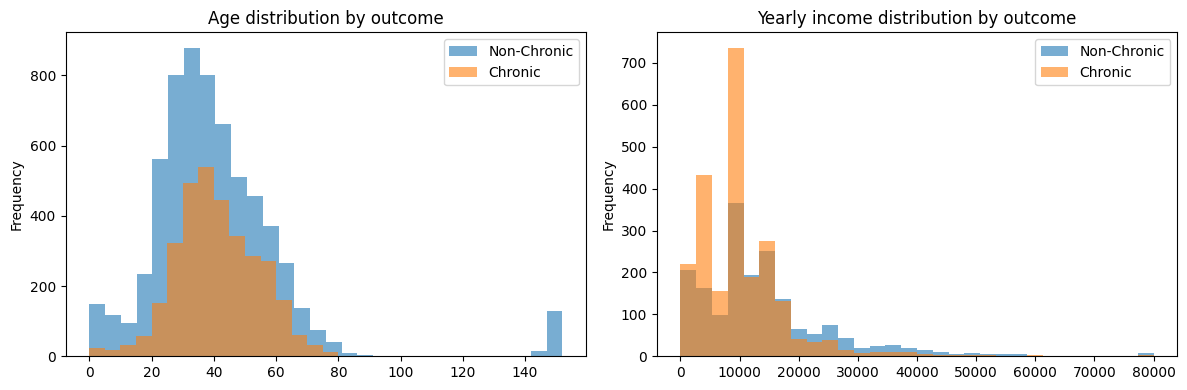

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['became_chronic']==0]['age'].plot(kind='hist', bins=30, alpha=0.6, label='Non-Chronic', ax=axes[0])
df[df['became_chronic']==1]['age'].plot(kind='hist', bins=30, alpha=0.6, label='Chronic', ax=axes[0])
axes[0].set_title('Age distribution by outcome')
axes[0].legend()

df[df['became_chronic']==0]['yearly_income'].clip(0, 80000).plot(
    kind='hist', bins=30, alpha=0.6, label='Non-Chronic', ax=axes[1])
df[df['became_chronic']==1]['yearly_income'].clip(0, 80000).plot(
    kind='hist', bins=30, alpha=0.6, label='Chronic', ax=axes[1])
axes[1].set_title('Yearly income distribution by outcome')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Binary clinical features

In [ ]:
binary_cols = ['tri_morbidity', 'returned_from_housing', 'first_homeless_episode', 'has_income', 'has_very_low_income']
summary = pd.DataFrame({
    'n_positive': df[binary_cols].sum(),
    'chronic_rate_positive': [df[df[c]==1]['became_chronic'].mean() for c in binary_cols],
    'chronic_rate_negative': [df[df[c]==0]['became_chronic'].mean() for c in binary_cols],
}).round(3)
print(summary)

                        n_positive  chronic_rate_positive  \
tri_morbidity                  411                  0.754   
returned_from_housing          207                  0.430   
first_homeless_episode        1424                  0.546   
has_income                    4093                  0.565   
has_very_low_income           3218                  0.611   

                        chronic_rate_negative  
tri_morbidity                           0.322  
returned_from_housing                   0.338  
first_homeless_episode                  0.304  
has_income                              0.173  
has_very_low_income                     0.203  


## 9. Train/test split verification

In [ ]:
from src.config import TRAIN_TEST_DATE

train_mask = training_df['Date Client Record Was Created'] < TRAIN_TEST_DATE
test_mask  = training_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE

print(f"Train: {train_mask.sum():,} clients ({train_mask.mean():.1%})")
print(f"Test:  {test_mask.sum():,} clients ({test_mask.mean():.1%})")
print(f"\nChronic rate — Train: {training_df[train_mask]['became_chronic'].mean():.1%}")
print(f"Chronic rate — Test:  {training_df[test_mask]['became_chronic'].mean():.1%}")

Train: 7,227 clients (75.5%)
Test:  2,349 clients (24.5%)

Chronic rate — Train: 39.3%
Chronic rate — Test:  17.9%


## 10. Save processed dataset

In [ ]:
# Preview before saving
print(f"Shape: {training_df.shape}")
print(f"Columns: {list(training_df.columns)}")
print(f"\nChronic rate: {training_df['became_chronic'].mean():.1%}")
print(f"\nFirst 10 rows (Phase A features only):")
from src.config import PHASE_A_FEATURES
training_df[PHASE_A_FEATURES + ['became_chronic']].head(10)

Shape: (9576, 69)
Columns: ['Dummy Client ID', 'Date', 'Date Client Record Was Created', 'Geographic Region', 'Age', 'Gender Identity', 'Days Since Last Activity', 'Indigenous Status', 'Veteran Status', 'Citizenship and Immigration Status', 'Last Known Housing Type', 'Recent Interaction Module', 'Recent Interaction Date', 'Household Type', 'Acuity - Triage Start Date', 'Acuity - Triage Score', 'Acuity - Triage Type', 'Acuity - Full Assessment Start Date', 'Acuity - Full Assessment Score', 'Acuity - Full Assessment Type', 'Tri-Morbidity', 'Current Episode Days Homeless', 'Days Homeless in Lifetime', 'Chronic Homelessness Y/N', 'Days Homeless In Past Year', 'Days Homeless in the Last 3 Years', 'Days Unsheltered Homeless in Lifetime', 'Percentage of Housing History Completed Over Last 30 Days', 'First Homeless Episode Y/N', 'First Homeless Episode In Last 30 Days Y/N', 'New Client In 30 Days Y/N', 'Returned From Housing Y/N', 'Returned From Inactive Y/N', 'City Name Where Last Housed', 'H

,entry_year,entry_season,days_before_first_snapshot,age,gender,indigenous_status,veteran_status,immigration_status,household_type,has_income,income_source,income_source_missing,yearly_income,yearly_income_missing,annual_income_range,has_very_low_income,tri_morbidity,returned_from_housing,first_homeless_episode,became_chronic
0,2024,Fall,270,39,Male,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,1,Ontario Works (OW),0,8400.0,0,"Very Low (0-19,999)",1,0,0,1,1
1,2022,Summer,184,9,Male,Non-Indigenous,Not a Veteran,Canadian Citizen,Family,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
2,2007,Winter,6370,32,Female,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
3,2024,Summer,8,50,Female,Indigenous,Not a Veteran,Canadian Citizen,Single,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
4,2024,Summer,349,45,Male,Non-Indigenous,Not a Veteran,Refugee,Family,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
5,2023,Summer,25,63,Female,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
6,2024,Winter,562,67,Male,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,1,Pension,0,14472.0,0,"Very Low (0-19,999)",1,0,0,0,1
7,2023,Summer,19,52,Female,Indigenous,Not a Veteran,Canadian Citizen,Single,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0
8,2022,Fall,238,46,Male,Unknown,Not a Veteran,Unknown,Single,1,Ontario Works (OW),0,8796.0,0,"Very Low (0-19,999)",1,0,0,1,1
9,2023,Winter,142,39,Male,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0


In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)

training_df.to_parquet('../data/processed/training_dataset.parquet', index=False)
print(f"Saved: {training_df.shape[0]:,} rows x {training_df.shape[1]} cols")
print("Path: data/processed/training_dataset.parquet")

Saved: 9,576 rows x 69 cols
Path: data/processed/training_dataset.parquet


In [ ]:

training_df.to_csv('../data/processed/training_dataset.csv', index=False)
training_df.head(10)


,Dummy Client ID,Date,Date Client Record Was Created,Geographic Region,Age,Gender Identity,Days Since Last Activity,Indigenous Status,Veteran Status,Citizenship and Immigration Status,Last Known Housing Type,Recent Interaction Module,Recent Interaction Date,Household Type,Acuity - Triage Start Date,Acuity - Triage Score,Acuity - Triage Type,Acuity - Full Assessment Start Date,Acuity - Full Assessment Score,Acuity - Full Assessment Type,Tri-Morbidity,Current Episode Days Homeless,Days Homeless in Lifetime,Chronic Homelessness Y/N,Days Homeless In Past Year,...,indigenous_status,veteran_status,immigration_status,household_type,age,last_housed_location,is_local_region,geo_missing,has_income,income_source,income_source_missing,yearly_income,yearly_income_missing,annual_income_range,has_very_low_income,tri_morbidity,returned_from_housing,first_homeless_episode,became_chronic,date_became_chronic,days_to_chronic,last_known_housing_category,last_known_housing_missing,first_intervention_type,days_since_last_activity
0,A102A28,2025-07-31,2024-11-02 17:33:24,Kitchener,39,Male,28.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - HOF ShelterCare,Admissions,2025-07-29 03:00:42,Single,NaT,NaN,Select an option,2025-06-25 11:44:00,24.0,SPDAT_V4,N,297.0,297.0,Y,297.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,39,Waterloo Region,1.0,0,1,Ontario Works (OW),0,8400.0,0,"Very Low (0-19,999)",1,0,0,1,1,2025-07-31,270.0,Emergency Shelter,0,Admissions,28.0
1,A109E15,2023-01-31,2022-07-30 23:13:41,None,9,Male,181.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: Motels - YW,Admissions,2022-08-04 18:05:00,Family,NaT,NaN,None,NaT,NaN,None,N,NaN,5.0,N,5.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Family,9,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Motel,0,Admissions,181.0
2,A110B58,2024-07-31,2007-02-21 00:00:00,This Community,32,Female,2.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - Cambridge Shelter,Goods and Services,2024-08-13 15:27:00,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,9.0,N,NaN,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,32,Never Housed/Unknown,1.0,0,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Cambridge Shelter,0,Goods and Services,2.0
3,A116Q99,2024-08-31,2024-08-22 15:40:42,None,50,Female,24.0,Métis,Not a Veteran,Canadian Citizen - Born in Canada,None,Goods and Services,2024-08-22 15:40:51,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,NaN,N,NaN,...,Indigenous,Not a Veteran,Canadian Citizen,Single,50,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Unknown,1,Goods and Services,24.0
4,A121N81,2025-07-31,2024-08-15 12:10:28,None,45,Male,165.0,Non-Indigenous,Not a Veteran,Refugee Claimant,Stay at: Motels - YW Families,Case Management,2025-03-14 13:39:00,Family,NaT,NaN,Select an option,NaT,NaN,Select an option,N,NaN,63.0,N,52.0,...,Non-Indigenous,Not a Veteran,Refugee,Family,45,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Motel,0,Case Management,165.0
5,A126F64,2023-07-31,2023-07-05 15:11:29,None,63,Female,27.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,None,Goods and Services,2023-07-05 15:11:49,Single,NaT,NaN,None,NaT,NaN,None,N,NaN,NaN,N,NaN,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,63,Never Housed/Unknown,NaN,1,0,NaN,1,NaN,1,No Income / Not Reported,0,0,0,0,0,NaT,NaN,Unknown,1,Goods and Services,27.0
6,A130G98,2025-07-31,2024-01-15 13:26:56,None,67,Male,28.0,Non-Indigenous,Not a Veteran,Canadian Citizen - Born in Canada,Stay at: ES - HOF ShelterCare,Admissions,2025-07-29 03:00:42,Single,NaT,NaN,Select an option,2025-06-17 13:00:00,12.0,SPDAT_V4,N,756.0,1729.0,Y,365.0,...,Non-Indigenous,Not a Veteran,Canadian Citizen,Single,67,Waterloo Region,NaN,1,1,Pension,0,14472.0,0,"Very Low (0-19,999)",1,0,0,0,1,2025-07-31,562.0,Emergency Shelter,0,Admissions,28.0
7,A130Q87,2023-07-31,

---
## Phase B — Service Feature EDA

Exploratory analysis of the 4 new Phase B features:
1. `last_known_housing_category` — 63 raw values grouped into 9 categories
2. `last_known_housing_missing` — flag for missing housing type
3. `first_intervention_type` — Recent Interaction Module at first snapshot
4. `days_since_last_activity` — Days Since Last Activity at first snapshot

Plus `first_meaningful_intervention` (used in Model What-if, not Model 1).

### Phase B-1: Last Known Housing Type — raw distribution (top 20)

In [ ]:
from src.feature_engineering import build_service_features, build_whatif_features
from src.config import HOUSING_TYPE_MAPPING, PHASE_B_ALL_FEATURES

# Build Phase B features
service_df = build_service_features(cam)
whatif_df  = build_whatif_features(cam)

print(f"Service features shape: {service_df.shape}")
print(f"What-if features shape: {whatif_df.shape}")
service_df.head(5)

Service features shape: (9576, 5)
What-if features shape: (9576, 2)


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:245: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_first_meaningful)


,Dummy Client ID,last_known_housing_category,last_known_housing_missing,first_intervention_type,days_since_last_activity
0,A102A28,Emergency Shelter,0,Admissions,28.0
1,A109E15,Motel,0,Admissions,181.0
2,A110B58,Cambridge Shelter,0,Goods and Services,2.0
3,A116Q99,Unknown,1,Goods and Services,24.0
4,A121N81,Motel,0,Case Management,165.0


In [ ]:
# Raw distribution — top 20 individual values
raw_housing = cam['Last Known Housing Type'].value_counts(dropna=False).head(20)
total_rows = len(cam)
print("Top 20 individual values (all snapshots):")
for val, cnt in raw_housing.items():
    marker = " ◄ >10%" if cnt / total_rows > 0.10 else ""
    print(f"  {str(val):<55} {cnt:>6,}  ({cnt/total_rows:.1%}){marker}")

Top 20 individual values (all snapshots):
  nan                                                     12,868  (21.9%) ◄ >10%
  Stay at: ES - Cambridge Shelter                          6,137  (10.5%) ◄ >10%
  Makeshift / Street                                       3,927  (6.7%)
  Stay at: ES - The Working Centre                         3,585  (6.1%)
  Stay at: ES - HOF ShelterCare                            3,058  (5.2%)
  Couch Surfing – Staying with Friends / Family / Acquaintances  3,013  (5.1%)
  Stay at: ES - SHIP                                       2,515  (4.3%)
  Stay at: ES - YW Shelter                                 2,429  (4.1%)
  Stay at: Motels - YW                                     2,269  (3.9%)
  Encampment/Campsite                                      2,125  (3.6%)
  Rental at Market Price                                   1,897  (3.2%)
  Stay at: ES - oneROOF                                    1,281  (2.2%)
  Stay at: ES - TWC Erbs Road Shelter                      1

### Phase B-2: last_known_housing_category — 9-category grouping + chronic rate

last_known_housing_category distribution (first snapshot per client):
                             clients  chronic_rate     %
last_known_housing_category                             
Unknown                         2906         0.000  30.3
Emergency Shelter               1974         0.500  20.6
Motel                           1126         0.410  11.8
Cambridge Shelter               1037         0.440  10.8
Street/Encampment                869         0.783   9.1
Couch Surfing/Family             739         0.518   7.7
Stable Housing                   507         0.107   5.3
Transitional Housing             265         0.736   2.8
Institutional                    153         0.268   1.6


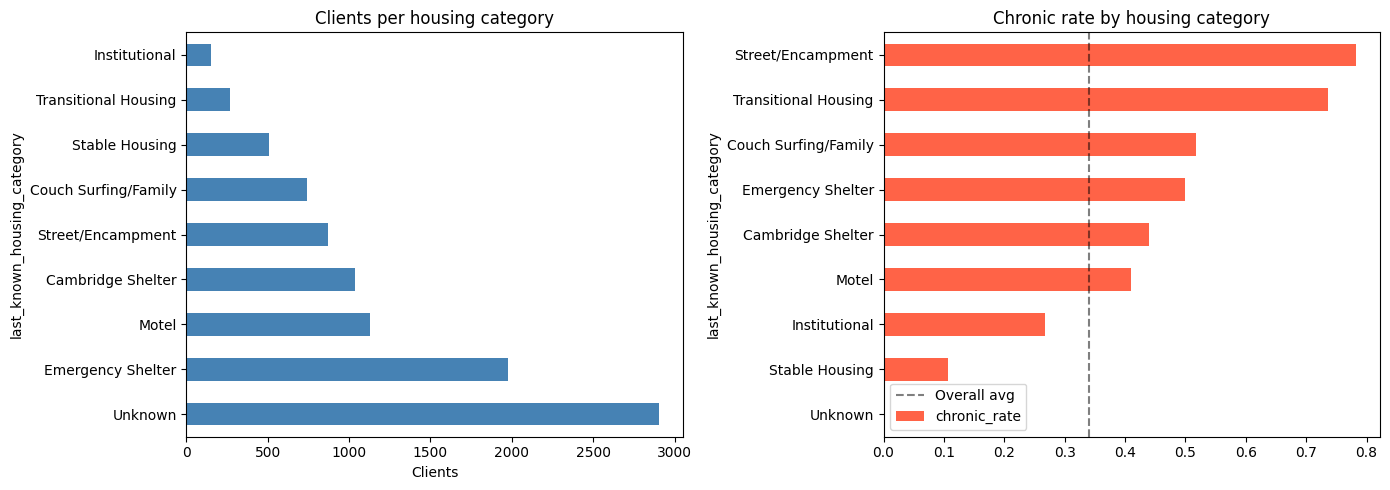

In [ ]:
# Grouped distribution (first snapshot per client) + chronic rate
svc = service_df.merge(training_df[['Dummy Client ID', 'became_chronic']], on='Dummy Client ID')

housing_summary = (
    svc.groupby('last_known_housing_category', observed=True)
       .agg(clients=('Dummy Client ID', 'count'),
            chronic_rate=('became_chronic', 'mean'))
       .sort_values('clients', ascending=False)
)
housing_summary['%'] = (housing_summary['clients'] / len(svc) * 100).round(1)
housing_summary['chronic_rate'] = housing_summary['chronic_rate'].round(3)
print("last_known_housing_category distribution (first snapshot per client):")
print(housing_summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
housing_summary['clients'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Clients per housing category')
axes[0].set_xlabel('Clients')
housing_summary['chronic_rate'].sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Chronic rate by housing category')
axes[1].axvline(svc['became_chronic'].mean(), color='black', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].legend()
plt.tight_layout()
plt.show()

### Phase B-3: first_intervention_type — distribution + chronic rate

first_intervention_type distribution (first snapshot per client):
                         clients  chronic_rate     %
first_intervention_type                             
Goods and Services          4439         0.175  46.4
Admissions                  3105         0.565  32.4
Group Activities             773         0.330   8.1
Case Management              676         0.478   7.1
Client Details               431         0.165   4.5
SPDAT                         62         0.710   0.6
Service Restrictions          46         0.565   0.5
Housing Placement             22         0.273   0.2
Follow Ups                    12         0.083   0.1
Housing Retention             10         0.300   0.1


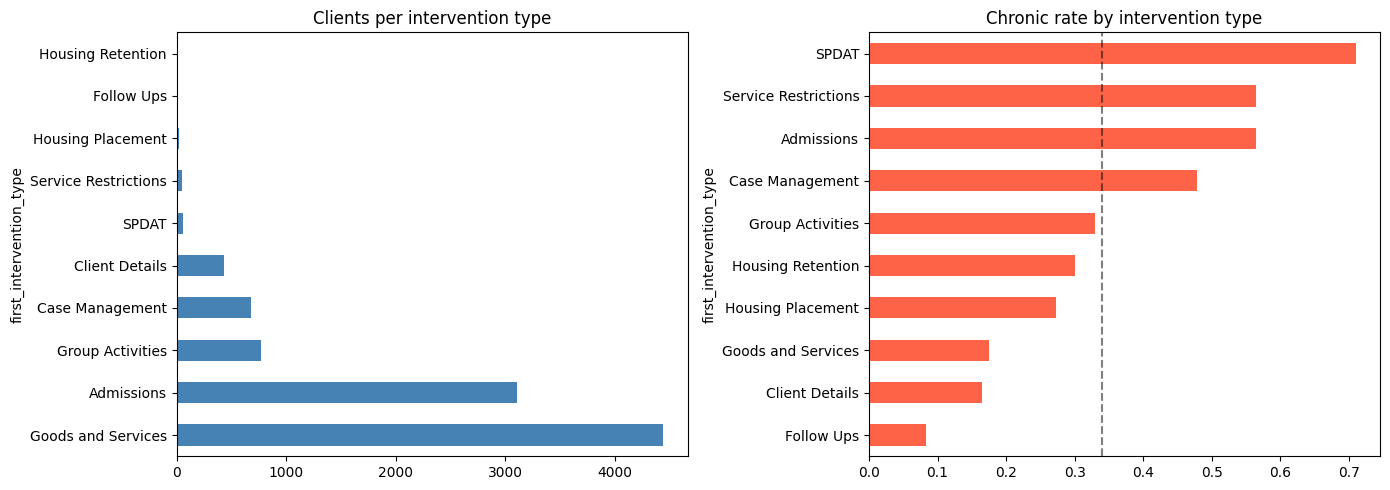

In [ ]:
intervention_summary = (
    svc.groupby('first_intervention_type', observed=True)
       .agg(clients=('Dummy Client ID', 'count'),
            chronic_rate=('became_chronic', 'mean'))
       .sort_values('clients', ascending=False)
)
intervention_summary['%'] = (intervention_summary['clients'] / len(svc) * 100).round(1)
intervention_summary['chronic_rate'] = intervention_summary['chronic_rate'].round(3)
print("first_intervention_type distribution (first snapshot per client):")
print(intervention_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
intervention_summary['clients'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Clients per intervention type')
intervention_summary['chronic_rate'].sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Chronic rate by intervention type')
axes[1].axvline(svc['became_chronic'].mean(), color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Phase B-4: days_since_last_activity + first_meaningful_intervention

In [ ]:
print("days_since_last_activity — missing rate:")
print(f"  Missing: {svc['days_since_last_activity'].isna().mean():.1%}")
print(f"  Mean: {svc['days_since_last_activity'].mean():.0f} days")
print(f"  Median: {svc['days_since_last_activity'].median():.0f} days")

print("\nfirst_meaningful_intervention distribution:")
wif = whatif_df.merge(training_df[['Dummy Client ID', 'became_chronic']], on='Dummy Client ID')
wif_summary = (
    wif.groupby('first_meaningful_intervention')
       .agg(clients=('Dummy Client ID', 'count'),
            chronic_rate=('became_chronic', 'mean'))
       .sort_values('clients', ascending=False)
)
wif_summary['%'] = (wif_summary['clients'] / len(wif) * 100).round(1)
wif_summary['chronic_rate'] = wif_summary['chronic_rate'].round(3)
print(wif_summary.to_string())

days_since_last_activity — missing rate:
  Missing: 0.0%
  Mean: 91 days
  Median: 19 days

first_meaningful_intervention distribution:
                               clients  chronic_rate     %
first_meaningful_intervention                             
Goods and Services                4826         0.213  50.4
No meaningful intervention        2388         0.430  24.9
Case Management                   1078         0.583  11.3
Group Activities                  1023         0.417  10.7
Service Restrictions               102         0.598   1.1
SPDAT                               87         0.747   0.9
Housing Placement                   46         0.348   0.5
Follow Ups                          14         0.143   0.1
Housing Retention                   12         0.250   0.1


### Phase B-5: Anti-leakage check — Phase B features

In [ ]:
from src.config import LEAKY_COLS, PHASE_B_ALL_FEATURES

# Rebuild X with 23 features and check for leakage
X_b, y_b = get_X_y(training_df)  # now uses PHASE_B_ALL_FEATURES by default

leaky_in_X = [c for c in LEAKY_COLS if c in X_b.columns]
if leaky_in_X:
    print(f"WARNING: Leaky columns found in X: {leaky_in_X}")
else:
    print("OK — No leaky columns in Phase B feature matrix")

print(f"\nX shape: {X_b.shape}  (expected: 9576 x 23)")
print(f"\nAll 23 features:")
for i, f in enumerate(X_b.columns, 1):
    tag = " ← Phase B" if f in ['last_known_housing_category',
                                  'last_known_housing_missing',
                                  'first_intervention_type',
                                  'days_since_last_activity'] else ""
    print(f"  {i:2}. {f}{tag}")

print(f"\nNull rates in Phase B features:")
b_features = ['last_known_housing_category', 'last_known_housing_missing',
              'first_intervention_type', 'days_since_last_activity']
print(X_b[b_features].isna().mean().round(3).to_string())

OK — No leaky columns in Phase B feature matrix

X shape: (9576, 23)  (expected: 9576 x 23)

All 23 features:
   1. entry_year
   2. entry_season
   3. days_before_first_snapshot
   4. age
   5. gender
   6. indigenous_status
   7. veteran_status
   8. immigration_status
   9. household_type
  10. has_income
  11. income_source
  12. income_source_missing
  13. yearly_income
  14. yearly_income_missing
  15. annual_income_range
  16. has_very_low_income
  17. tri_morbidity
  18. returned_from_housing
  19. first_homeless_episode
  20. last_known_housing_category ← Phase B
  21. last_known_housing_missing ← Phase B
  22. first_intervention_type ← Phase B
  23. days_since_last_activity ← Phase B

Null rates in Phase B features:
last_known_housing_category    0.0
last_known_housing_missing     0.0
first_intervention_type        0.0
days_since_last_activity       0.0
